<style>
@import url('https://fonts.googleapis.com/css2?family=Cinzel:wght@600&display=swap');
</style>

<div style="background-color:#3B7556; padding: 20px;  text-align: center; color: #ffff; font-family: 'Cinzel', san-serif; font-size: 28px;">
    <strong> <u> Future Intern: Data Science & Analytics</u> </strong><br>
        <div style='font-size:24px,color:'>Future_DS_03 </div>
        <div style="font-size: 24px,color:">Name: Emely Kwizera</div>
        <div style="font-size: 24px,color:"> Date: January 18, 2026</div>
        
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
import numpy as np 
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [4]:
df = pd.read_excel(r"D:\Future Interns\Future_DS_03\finalDataset0.2.xlsx")
df.head()


,teaching,teaching.1,coursecontent,coursecontent.1,examination,Examination,labwork,labwork.1,library_facilities,library_facilities,extracurricular,extracurricular.1
0,0,teacher are punctual but they should also give...,0.0,content of courses are average,1.0,examination pattern is good,-1,"not satisfactory, lab work must include latest...",0.0,library facilities are good but number of book...,1,extracurricular activities are excellent and p...
1,1,Good,-1.0,Not good,1.0,Good,1,Good,-1.0,Not good,1,Good
2,1,Excellent lectures are delivered by teachers a...,1.0,All courses material provide very good knowled...,1.0,Exam pattern is up to the mark and the Cgpa de...,1,Lab work is properly covered in the labs by th...,1.0,Library facilities are excellent in terms of g...,1,Extra curricular activities also help students...
3,1,Good,-1.0,Content of course is perfectly in line with th...,-1.0,Again the university tests students of their a...,1,Good,0.0,Its the best thing i have seen in this univers...,-1,Complete wastage of time. Again this opinion i...
4,1,teachers give us all the information required ...,1.0,content of courses improves my knowledge,1.0,examination pattern is good,1,practical work provides detail knowledge of th...,1.0,library has huge collection of books from diff...,1,extracurricular activities increases mental an...


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   teaching             185 non-null    int64  
 1   teaching.1           185 non-null    object 
 2   coursecontent        184 non-null    float64
 3   coursecontent.1      185 non-null    object 
 4   examination          184 non-null    float64
 5   Examination          185 non-null    object 
 6   labwork              185 non-null    int64  
 7   labwork.1            185 non-null    object 
 8   library_facilities   182 non-null    float64
 9    library_facilities  185 non-null    object 
 10  extracurricular      185 non-null    int64  
 11  extracurricular.1    185 non-null    object 
dtypes: float64(3), int64(3), object(6)
memory usage: 17.5+ KB


<p style="font-family: 'Times New Roman'; font-size: 18px !important;">
We have 185 Student's feedback as comments and ratings in teaching, course content, examination, lab work, library facilities, and extracurricular. 
</p>

# Renaming columns

In [6]:
df.columns = [
    "Teaching_Rating", "Teaching_Comment",
    "CourseContent_Rating", "CourseContent_Comment",
    "Examination_Rating", "Examination_Comment",
    "LabWork_Rating", "LabWork_Comment",
    "Library_Rating", "Library_Comment",
    "ExtraCurricular_Rating", "ExtraCurricular_Comment"
]


In [7]:
df.isnull().sum()

Teaching_Rating            0
Teaching_Comment           0
CourseContent_Rating       1
CourseContent_Comment      0
Examination_Rating         1
Examination_Comment        0
LabWork_Rating             0
LabWork_Comment            0
Library_Rating             3
Library_Comment            0
ExtraCurricular_Rating     0
ExtraCurricular_Comment    0
dtype: int64

In [8]:
df.ffill(inplace=True)

In [9]:
df.fillna(method="ffill", inplace=True)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20264\3651561093.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


# Rating Analysis

### Average per category

In [10]:
avg_ratings = df[
    ["Teaching_Rating","CourseContent_Rating","Examination_Rating",
     "LabWork_Rating","Library_Rating","ExtraCurricular_Rating"]
].mean()

avg_ratings


Teaching_Rating           0.670270
CourseContent_Rating      0.535135
Examination_Rating        0.578378
LabWork_Rating            0.513514
Library_Rating            0.529730
ExtraCurricular_Rating    0.767568
dtype: float64

## Visualization

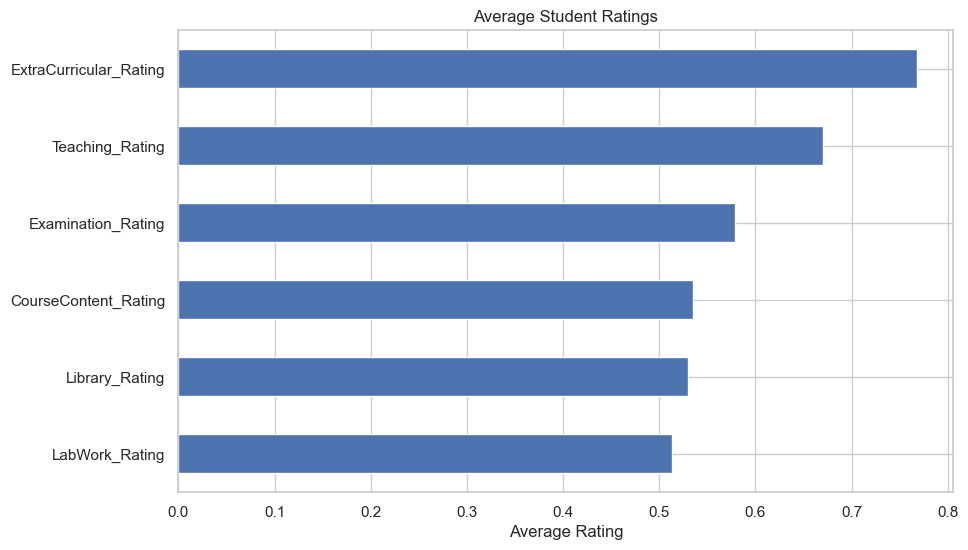

In [11]:
avg_ratings.sort_values().plot(
    kind="barh", title="Average Student Ratings"
)
plt.xlabel("Average Rating")
plt.show()


### Insights

<p style="font-family: 'Times New Roman'; font-size: 18px !important;">
The average ratings across different campus experience areas indicate an overall positive student perception, with noticeable variation between categories.<br></br>Extra-curricular activities received the highest average rating (0.77), suggesting that students are highly satisfied with opportunities beyond academics, such as clubs, events, and cultural activities. This highlights the campus’s strength in promoting holistic student development.<br></br>Teaching quality also scored strongly (0.67), reflecting that students generally appreciate the instructors’ approach, clarity, and engagement in the classroom.<br></br>Examination practices show a moderate level of satisfaction (0.58), indicating that while students find assessments acceptable, there may be room for improvement in fairness, structure, or alignment with course content.<br></br>Ratings for course content (0.54), library facilities (0.53), and laboratory work (0.51) are comparatively lower, suggesting these areas may benefit from enhancement. Improvements such as updated resources, better lab equipment, or more structured course materials could positively impact student experience.
</p>

# Sentiment Analysis

### Sentiment Function using TextBlob

In [12]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"


## Apply Sentiment Analysis

In [13]:
df["Teaching_Sentiment"] = df["Teaching_Comment"].apply(get_sentiment)
df["CourseContent_Sentiment"] = df["CourseContent_Comment"].apply(get_sentiment)
df["Examination_Sentiment"] = df["Examination_Comment"].apply(get_sentiment)
df["LabWork_Sentiment"] = df["LabWork_Comment"].apply(get_sentiment)
df["Library_Sentiment"] = df["Library_Comment"].apply(get_sentiment)
df["ExtraCurricular_Sentiment"] = df["ExtraCurricular_Comment"].apply(get_sentiment)

df.head()


,Teaching_Rating,Teaching_Comment,CourseContent_Rating,CourseContent_Comment,Examination_Rating,Examination_Comment,LabWork_Rating,LabWork_Comment,Library_Rating,Library_Comment,ExtraCurricular_Rating,ExtraCurricular_Comment,Teaching_Sentiment,CourseContent_Sentiment,Examination_Sentiment,LabWork_Sentiment,Library_Sentiment,ExtraCurricular_Sentiment
0,0,teacher are punctual but they should also give...,0.0,content of courses are average,1.0,examination pattern is good,-1,"not satisfactory, lab work must include latest...",0.0,library facilities are good but number of book...,1,extracurricular activities are excellent and p...,Negative,Negative,Positive,Positive,Positive,Positive
1,1,Good,-1.0,Not good,1.0,Good,1,Good,-1.0,Not good,1,Good,Positive,Negative,Positive,Positive,Negative,Positive
2,1,Excellent lectures are delivered by teachers a...,1.0,All courses material provide very good knowled...,1.0,Exam pattern is up to the mark and the Cgpa de...,1,Lab work is properly covered in the labs by th...,1.0,Library facilities are excellent in terms of g...,1,Extra curricular activities also help students...,Positive,Positive,Positive,Positive,Positive,Positive
3,1,Good,-1.0,Content of course is perfectly in line with th...,-1.0,Again the university tests students of their a...,1,Good,0.0,Its the best thing i have seen in this univers...,-1,Complete wastage of time. Again this opinion i...,Positive,Positive,Positive,Positive,Positive,Positive
4,1,teachers give us all the information required ...,1.0,content of courses improves my knowledge,1.0,examination pattern is good,1,practical work provides detail knowledge of th...,1.0,library has huge collection of books from diff...,1,extracurricular activities increases mental an...,Neutral,Neutral,Positive,Neutral,Positive,Negative


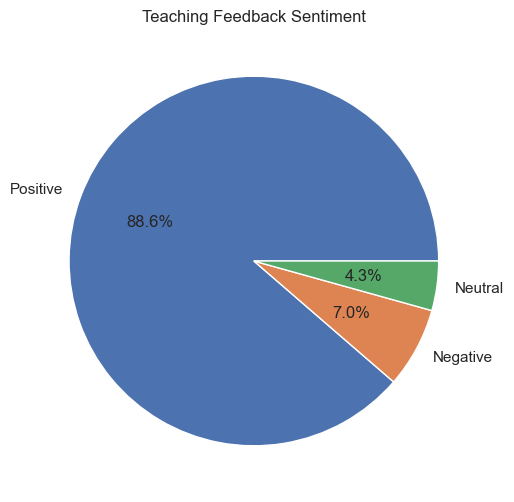

In [14]:
df["Teaching_Sentiment"].value_counts().plot(
    kind="pie", autopct="%1.1f%%",
    title="Teaching Feedback Sentiment"
)
plt.ylabel("")
plt.show()


## Interpretation

<p style="font-family: 'Times New Roman'; font-size: 18px !important;">
88.6% of the feedback is positive
This indicates a very high level of satisfaction with teaching quality. Most students expressed appreciation for aspects such as clarity, engagement, and overall teaching effectiveness.<br></br>7.0% of the feedback is negative
A small but important portion of students reported dissatisfaction. While this group is limited, it highlights specific pain points that should be reviewed to further improve teaching outcomes.<br></br>4.3% of the feedback is neutral
Neutral comments typically reflect descriptive or balanced feedback without strong emotional language, suggesting areas where students neither strongly approve nor disapprove.
</p>

## Word Cloud 

### Teaching feedback word cloud

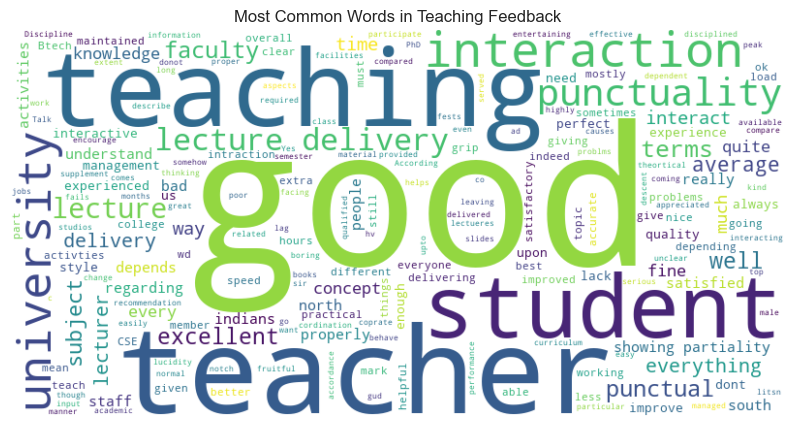

In [15]:
text = " ".join(df["Teaching_Comment"])

wordcloud = WordCloud(
    width=800, height=400,
    background_color="white"
).generate(text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Teaching Feedback")
plt.show()


<p style="font-family: 'Times New Roman'; font-size: 18px !important;">
I used a word cloud to visually summarize the most frequently mentioned terms in student teaching feedback. Larger words represent topics students talked about most often, which helps quickly identify key themes such as teaching quality, interaction, punctuality, and lecture delivery.
</p>

<p style="font-family: 'Times New Roman'; font-size: 18px !important;">
The analysis of teaching feedback reveals that students most frequently emphasize positive aspects of teaching quality. Commonly mentioned themes include strong instructor–student interaction, effective lecture delivery, and punctuality, indicating that students value clear communication and structured classroom sessions. Additionally, frequent references to faculty engagement suggest that instructors’ involvement and approachability play a significant role in shaping a positive learning experience.
</p>

# Correlatiion Beween Ratings 

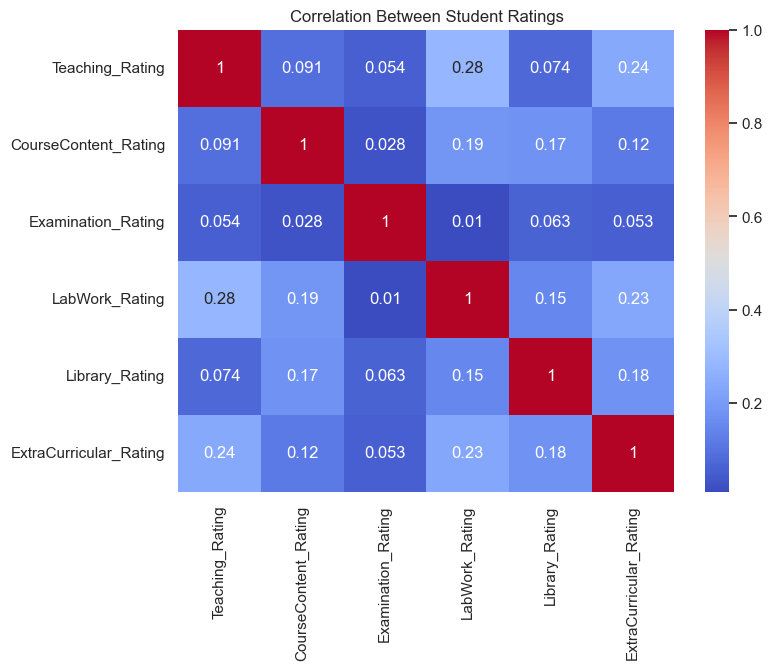

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[[
        "Teaching_Rating","CourseContent_Rating",
        "Examination_Rating","LabWork_Rating",
        "Library_Rating","ExtraCurricular_Rating"
    ]].corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Correlation Between Student Ratings")
plt.show()


## Key Insights 

<p style="font-family: 'Times New Roman'; font-size: 18px !important;">
Teaching and Extra-Curricular Activities show a positive correlation (0.24), which indicates that students who report higher satisfaction with teaching quality also tend to rate extracurricular activities more positively. This suggests that effective teaching may contribute to broader student engagement and a more positive overall campus experience.<br></br>Teaching and Lab Work demonstrate a relatively stronger correlation (0.28), indicating that positive teaching experiences are often associated with better perceptions of laboratory work. This may imply that clear instruction and faculty guidance enhance students’ practical learning experiences in labs.<br></br>Course Content and Lab Work show a moderate correlation (0.19), suggesting that well-structured and relevant course content supports a more effective laboratory experience. When theoretical concepts are clearly aligned with practical applications, students tend to rate lab work more favorably.<br></br>Course Content and Library Facilities exhibit a positive correlation (0.17), indicating that students who are satisfied with course content also appreciate the availability and usefulness of library resources. This highlights the importance of academic support materials in reinforcing learning outcomes.<br></br>Library Facilities and Extra-Curricular Activities show a mild positive correlation (0.18), suggesting that access to supportive infrastructure contributes to an overall positive perception of campus life beyond academics.<br></br>Examination Ratings display very weak correlations with other categories, indicating that students’ perceptions of examinations are largely independent of teaching quality, facilities, or extracurricular experiences. This suggests that examination-related concerns may require separate evaluation and targeted improvements.
</p>

# Strategic Recommendation

<p style="font-family: 'Times New Roman'; font-size: 18px !important;">
We have seen that teaching quality receives consistently high ratings and overwhelmingly positive sentiment. This means that students value interactive lectures, punctuality, and faculty engagement as key contributors to their learning experience. Therefore, institutions should continue to invest in faculty development programs and encourage interactive teaching methods to maintain and scale this strength across departments.<br></br>We have seen a positive relationship between teaching quality and lab work satisfaction. This means that students’ practical learning experiences improve when theoretical concepts are clearly explained and supported by instructors. Therefore, institutions should strengthen the alignment between classroom teaching and laboratory sessions by improving lab instructions, faculty involvement, and practical resources.<br></br>We have seen that examination ratings show weak connections with other academic factors. This means that students evaluate assessments independently of teaching quality and campus facilities. Therefore, institutions should separately review examination design, grading transparency, and alignment with course content to address assessment-specific concerns.<br></br>We have seen moderate satisfaction levels related to course content and library facilities. This means that academic resources play a supporting but important role in student satisfaction. Therefore, institutions should regularly update course materials and enhance library resources, especially digital access, to better support student learning.<br></br>We have seen that extra-curricular activities receive some of the highest ratings and correlate positively with overall satisfaction. This means that non-academic engagement significantly enhances campus life. Therefore, institutions should continue expanding and promoting extra-curricular programs as a strategic tool to improve student engagement and well-being.<br><br>We have seen that sentiment analysis sometimes misclassifies complex or mixed feedback. This means that unstructured comments can limit analytical accuracy. Therefore, institutions should improve feedback form design by using guided questions and clearer prompts to collect more actionable and analyzable responses.
</p>